# Calcul des Indicateurs Techniques - SentiTrade-HMA v2.0

**Objectif:** Calculer les indicateurs techniques sur les données collectées  
**Données source:** `data/raw/financial_data_full.csv`  
**Indicateurs:** HMA, RSI, MACD, Bollinger Bands, Volume

**Note:** HMA (Hull Moving Average) est spécifiquement mentionné dans le titre du projet!


In [1]:
# Setup du projet
import sys
from pathlib import Path

project_root = Path.cwd().parent if 'notebooks' in str(Path.cwd()) else Path.cwd()
sys.path.insert(0, str(project_root))

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from src.utils.config import get_config
from src.utils.logger import get_logger
from src.data.preprocessors import TechnicalIndicatorCalculator

# Configuration
sns.set_style('darkgrid')
plt.rcParams['figure.dpi'] = 100

logger = get_logger(__name__)

print("✅ Imports réussis")
print(f"📁 Project root: {project_root}")


✅ Imports réussis
📁 Project root: c:\Users\lenovo\OneDrive\Bureau\cours\sentiTrade-HMA-V2


In [2]:
# Charger la configuration
config = get_config()
data_config = config.get_data_config()

# Charger les données collectées
data_path = config.data_dir / 'raw' / 'financial_data_full.csv'

print("="*70)
print("📂 CHARGEMENT DES DONNÉES")
print("="*70)
print(f"Source: {data_path}")

if not data_path.exists():
    print(f"❌ ERREUR: Fichier non trouvé!")
    print(f"   Assurez-vous d'avoir exécuté 01_data_collection.ipynb")
    raise FileNotFoundError(f"Fichier non trouvé: {data_path}")

data = pd.read_csv(data_path)
data['Date'] = pd.to_datetime(data['Date'])

print(f"✅ Données chargées")
print(f"  - Lignes: {len(data):,}")
print(f"  - Tickers: {data['Ticker'].nunique()}")
print(f"  - Période: {data['Date'].min()} → {data['Date'].max()}")
print(f"  - Colonnes: {list(data.columns)}")
print("="*70)


📂 CHARGEMENT DES DONNÉES
Source: c:\Users\lenovo\OneDrive\Bureau\cours\sentiTrade-HMA-V2\data\raw\financial_data_full.csv
✅ Données chargées
  - Lignes: 35,200
  - Tickers: 20
  - Période: 2018-01-02 00:00:00 → 2024-12-30 00:00:00
  - Colonnes: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker']


In [ ]:
# Aperçu des données
print("\n APERÇU DES DONNÉES BRUTES:\n")
display(data.head(10))
print("\nInfo dataset:")
data.info()


 APERÇU DES DONNÉES BRUTES:



,Date,Close,High,Low,Open,Volume,Ticker
0,2018-01-02,40.341888,40.351258,39.639313,39.850088,102223600,AAPL
1,2018-01-03,40.334858,40.878185,40.271629,40.405116,118071600,AAPL
2,2018-01-04,40.522221,40.625266,40.299739,40.407465,89738400,AAPL
3,2018-01-05,40.983582,41.070231,40.526908,40.618243,94640000,AAPL
4,2018-01-08,40.831348,41.126429,40.732985,40.831348,82271200,AAPL
5,2018-01-09,40.826668,40.997627,40.611212,40.878190,86336000,AAPL
6,2018-01-10,40.817284,40.819628,40.515178,40.552649,95839600,AAPL
7,2018-01-11,41.049145,41.098327,40.864135,40.887552,74670800,AAPL
8,2018-01-12,41.473042,41.536274,41.135805,41.259926,101672400,AAPL
9,2018-01-16,41.262264,42.011677,41.250554,41.662730,118263600,AAPL



Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35200 entries, 0 to 35199
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    35200 non-null  datetime64[ns]
 1   Close   35200 non-null  float64       
 2   High    35200 non-null  float64       
 3   Low     35200 non-null  float64       
 4   Open    35200 non-null  float64       
 5   Volume  35200 non-null  int64         
 6   Ticker  35200 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 1.9+ MB


In [ ]:
# Initialiser le calculateur d'indicateurs techniques
print("\n" + "="*70)
print(" INITIALISATION DU CALCULATEUR")
print("="*70)

calculator = TechnicalIndicatorCalculator()

# Lire la configuration des indicateurs
indicators_config = data_config['preprocessing']['technical_indicators']

print(f" Calculateur initialisé")
print(f"\n Indicateurs à calculer (depuis data_config.yaml):")
for indicator in indicators_config:
    print(f"  - {indicator['name']}: {indicator}")
print("="*70)


 INITIALISATION DU CALCULATEUR
 Calculateur initialisé

 Indicateurs à calculer (depuis data_config.yaml):
  - HMA: {'name': 'HMA', 'period': 20}
  - RSI: {'name': 'RSI', 'period': 14}
  - MACD: {'name': 'MACD', 'fast': 12, 'slow': 26, 'signal': 9}
  - BB: {'name': 'BB', 'period': 20, 'std': 2}
  - OBV: {'name': 'OBV'}
  - VWAP: {'name': 'VWAP'}


In [5]:
# Calculer tous les indicateurs techniques
print("\n CALCUL DES INDICATEURS TECHNIQUES...")
print("⏱️  Cela peut prendre 1-2 minutes pour 35,000+ lignes\n")

# Utiliser la méthode du calculateur
data_with_indicators = calculator.add_all_indicators(data)

print(f"\n CALCUL TERMINÉ!")
print(f"  - Lignes: {len(data_with_indicators):,}")
print(f"  - Colonnes originales: {len(data.columns)}")
print(f"  - Colonnes avec indicateurs: {len(data_with_indicators.columns)}")
print(f"  - Nouvelles colonnes: {len(data_with_indicators.columns) - len(data.columns)}")
print(f"\n Nouvelles colonnes ajoutées:")
new_cols = [col for col in data_with_indicators.columns if col not in data.columns]
for col in new_cols:
    print(f"  - {col}")



 CALCUL DES INDICATEURS TECHNIQUES...
⏱️  Cela peut prendre 1-2 minutes pour 35,000+ lignes

2026-01-08 13:38:46 - src.data.preprocessors - INFO - Calculating technical indicators...
2026-01-08 13:38:46 - src.data.preprocessors - INFO -    AAPL: Indicators calculated
2026-01-08 13:38:46 - src.data.preprocessors - INFO -    MSFT: Indicators calculated
2026-01-08 13:38:46 - src.data.preprocessors - INFO -    GOOGL: Indicators calculated
2026-01-08 13:38:46 - src.data.preprocessors - INFO -    NVDA: Indicators calculated
2026-01-08 13:38:46 - src.data.preprocessors - INFO -    META: Indicators calculated
2026-01-08 13:38:46 - src.data.preprocessors - INFO -    AMZN: Indicators calculated
2026-01-08 13:38:46 - src.data.preprocessors - INFO -    TSLA: Indicators calculated
2026-01-08 13:38:46 - src.data.preprocessors - INFO -    WMT: Indicators calculated
2026-01-08 13:38:46 - src.data.preprocessors - INFO -    JPM: Indicators calculated
2026-01-08 13:38:46 - src.data.preprocessors - INFO 

In [6]:
# Aperçu des données avec indicateurs
print("\n APERÇU DES DONNÉES AVEC INDICATEURS:\n")

# Sélectionner colonnes importantes pour affichage
cols_to_show = ['Date', 'Ticker', 'Close', 'HMA', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist']
display(data_with_indicators[cols_to_show].head(20))

print("\n Statistiques des indicateurs:")
indicator_cols = ['HMA', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist']
display(data_with_indicators[indicator_cols].describe())



 APERÇU DES DONNÉES AVEC INDICATEURS:



,Date,Ticker,Close,HMA,RSI,MACD,MACD_Signal,MACD_Hist
0,2018-01-02,AAPL,40.341888,NaN,NaN,0.000000,0.000000,0.000000
1,2018-01-03,AAPL,40.334858,NaN,NaN,-0.000561,-0.000112,-0.000449
2,2018-01-04,AAPL,40.522221,NaN,NaN,0.013952,0.002701,0.011252
3,2018-01-05,AAPL,40.983582,NaN,NaN,0.061968,0.014554,0.047414
4,2018-01-08,AAPL,40.831348,NaN,NaN,0.086737,0.028991,0.057746
5,2018-01-09,AAPL,40.826668,NaN,NaN,0.104781,0.044149,0.060632
6,2018-01-10,AAPL,40.817284,NaN,NaN,0.116975,0.058714,0.058261
7,2018-01-11,AAPL,41.049145,NaN,NaN,0.143692,0.075710,0.067982
8,2018-01-12,AAPL,41.473042,NaN,NaN,0.196802,0.099928,0.096874
9,2018-01-16,AAPL,41.262264,NaN,NaN,0.219355,0.123814,0.095542



 Statistiques des indicateurs:


,HMA,RSI,MACD,MACD_Signal,MACD_Hist
count,34760.000000,34940.000000,35200.000000,35200.000000,35200.000000
mean,131.814645,53.172436,0.554791,0.550605,0.004186
std,111.933883,16.963115,3.810769,3.551044,1.172642
min,3.099239,1.275109,-56.994680,-47.845443,-16.104680
25%,40.133639,40.944402,-0.511607,-0.462300,-0.270779
50%,109.946816,53.417936,0.233777,0.233079,0.011128
75%,184.631107,65.653562,1.555707,1.487180,0.307792
max,640.801756,98.836479,40.538606,34.756622,10.296174


In [7]:
# Vérifier les valeurs manquantes (normales au début pour indicateurs)
print("\n VÉRIFICATION DES VALEURS MANQUANTES:")
print("="*70)

missing = data_with_indicators.isnull().sum()
missing_pct = (missing / len(data_with_indicators) * 100).round(2)

missing_df = pd.DataFrame({
    'Colonne': missing.index,
    'Manquants': missing.values,
    'Pourcentage': missing_pct.values
})

missing_df = missing_df[missing_df['Manquants'] > 0].sort_values('Manquants', ascending=False)

if len(missing_df) > 0:
    print("⚠️  Valeurs manquantes détectées (normal pour indicateurs):\n")
    display(missing_df)
    
    print("\n Explication:")
    print("  - Les indicateurs nécessitent un historique (ex: RSI = 14 jours)")
    print("  - Les premières lignes de chaque ticker ont des NaN")
    print("  - Ces lignes seront supprimées pour le training")
    
    # Calculer combien de lignes seront perdues
    rows_with_nan = data_with_indicators.isnull().any(axis=1).sum()
    rows_usable = len(data_with_indicators) - rows_with_nan
    pct_usable = (rows_usable / len(data_with_indicators) * 100)
    
    print(f"\n Impact:")
    print(f"  - Lignes avec NaN: {rows_with_nan:,}")
    print(f"  - Lignes utilisables: {rows_usable:,} ({pct_usable:.1f}%)")
else:
    print("✅ Aucune valeur manquante")

print("="*70)



 VÉRIFICATION DES VALEURS MANQUANTES:
⚠️  Valeurs manquantes détectées (normal pour indicateurs):



,Colonne,Manquants,Pourcentage
7,HMA,440,1.25
8,RSI,260,0.74



 Explication:
  - Les indicateurs nécessitent un historique (ex: RSI = 14 jours)
  - Les premières lignes de chaque ticker ont des NaN
  - Ces lignes seront supprimées pour le training

 Impact:
  - Lignes avec NaN: 440
  - Lignes utilisables: 34,760 (98.8%)



📊 GÉNÉRATION DES VISUALISATIONS...



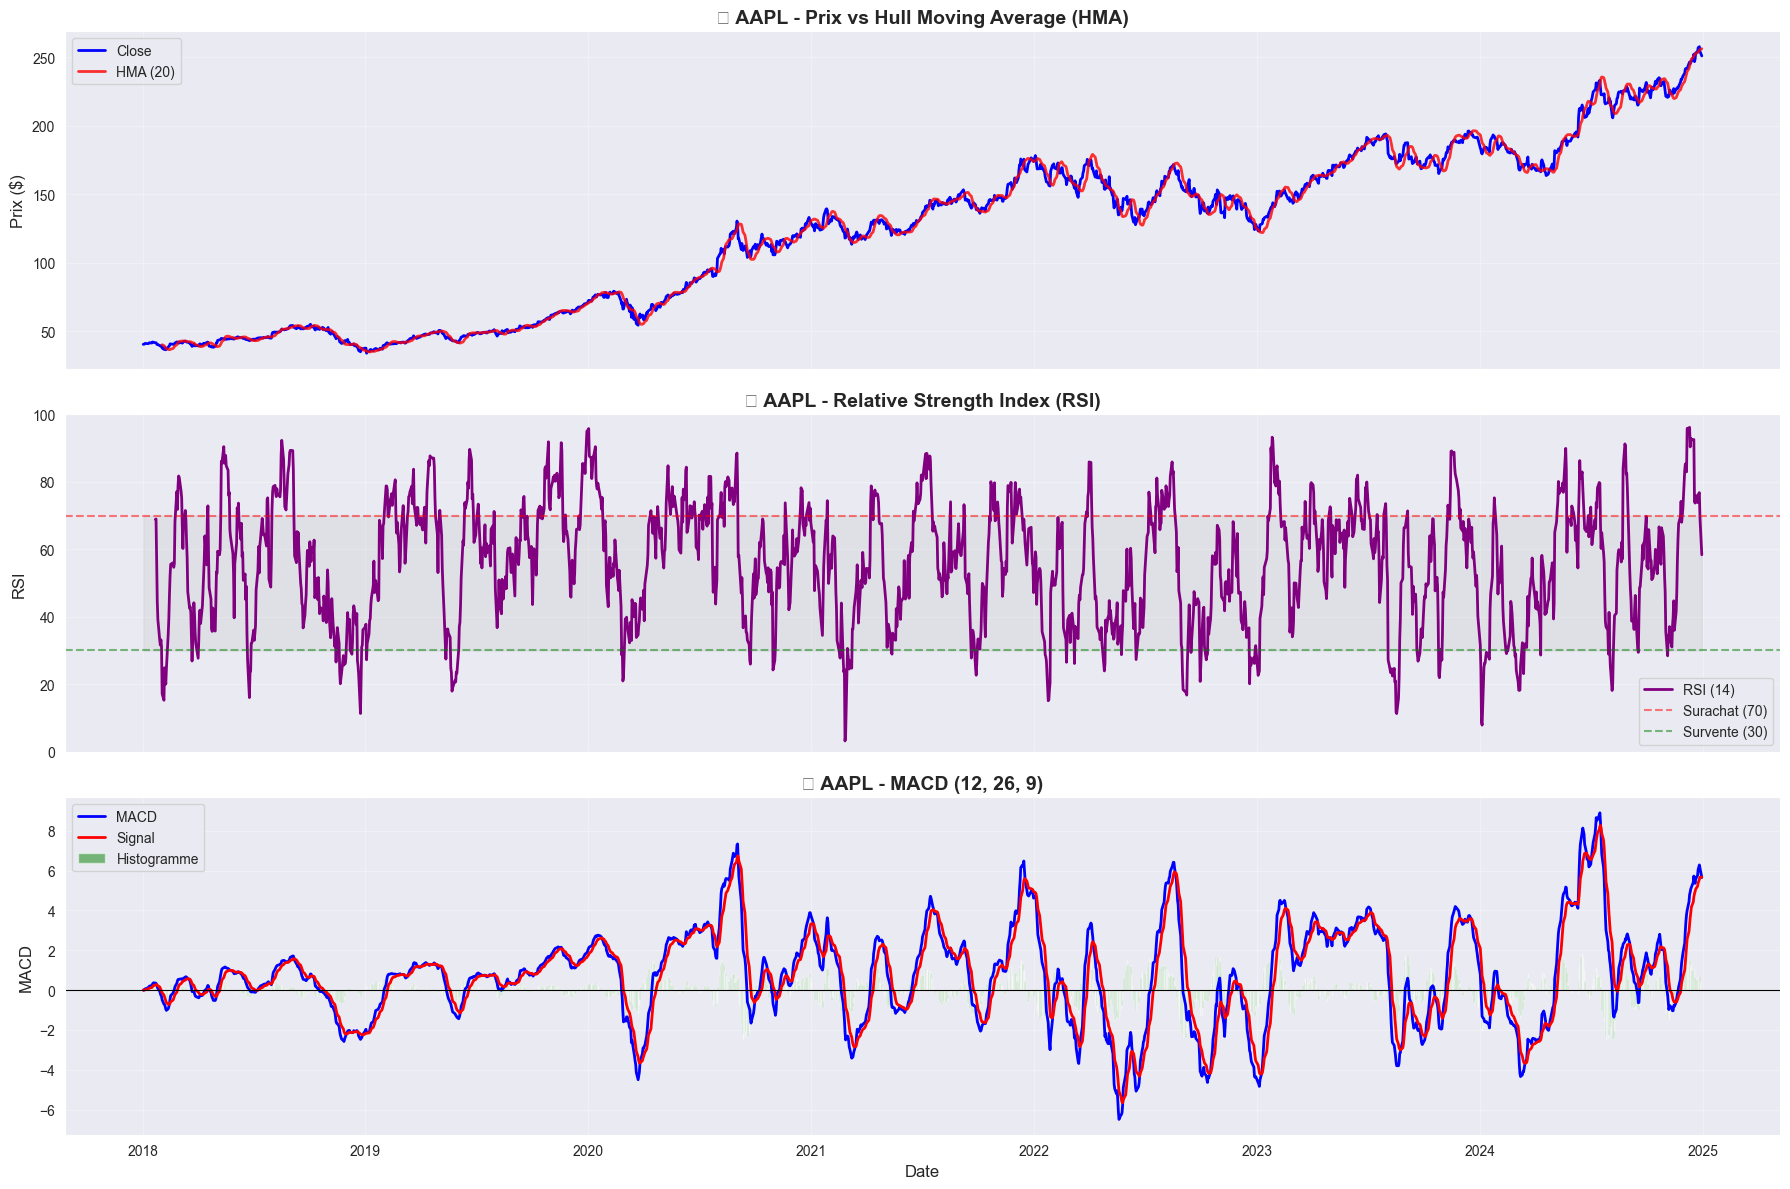

✅ Graphique 1/3: Indicateurs techniques pour AAPL


In [8]:
# Visualisation 1: HMA vs Close pour un ticker
print("\n📊 GÉNÉRATION DES VISUALISATIONS...\n")

# Choisir un ticker pour visualisation détaillée
sample_ticker = 'AAPL'
ticker_data = data_with_indicators[data_with_indicators['Ticker'] == sample_ticker].copy()
ticker_data = ticker_data.sort_values('Date')

fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)

# Panel 1: Prix + HMA
axes[0].plot(ticker_data['Date'], ticker_data['Close'], label='Close', linewidth=2, color='blue')
axes[0].plot(ticker_data['Date'], ticker_data['HMA'], label='HMA (20)', linewidth=2, color='red', alpha=0.8)
axes[0].set_ylabel('Prix ($)', fontsize=12)
axes[0].set_title(f'📈 {sample_ticker} - Prix vs Hull Moving Average (HMA)', fontsize=14, fontweight='bold')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

# Panel 2: RSI
axes[1].plot(ticker_data['Date'], ticker_data['RSI'], label='RSI (14)', linewidth=2, color='purple')
axes[1].axhline(70, color='red', linestyle='--', alpha=0.5, label='Surachat (70)')
axes[1].axhline(30, color='green', linestyle='--', alpha=0.5, label='Survente (30)')
axes[1].fill_between(ticker_data['Date'], 30, 70, alpha=0.1, color='gray')
axes[1].set_ylabel('RSI', fontsize=12)
axes[1].set_title(f'📊 {sample_ticker} - Relative Strength Index (RSI)', fontsize=14, fontweight='bold')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 100)

# Panel 3: MACD
axes[2].plot(ticker_data['Date'], ticker_data['MACD'], label='MACD', linewidth=2, color='blue')
axes[2].plot(ticker_data['Date'], ticker_data['MACD_Signal'], label='Signal', linewidth=2, color='red')
axes[2].bar(ticker_data['Date'], ticker_data['MACD_Hist'], label='Histogramme', alpha=0.5, color='green')
axes[2].axhline(0, color='black', linestyle='-', linewidth=0.8)
axes[2].set_ylabel('MACD', fontsize=12)
axes[2].set_xlabel('Date', fontsize=12)
axes[2].set_title(f'📊 {sample_ticker} - MACD (12, 26, 9)', fontsize=14, fontweight='bold')
axes[2].legend(loc='best')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"✅ Graphique 1/3: Indicateurs techniques pour {sample_ticker}")


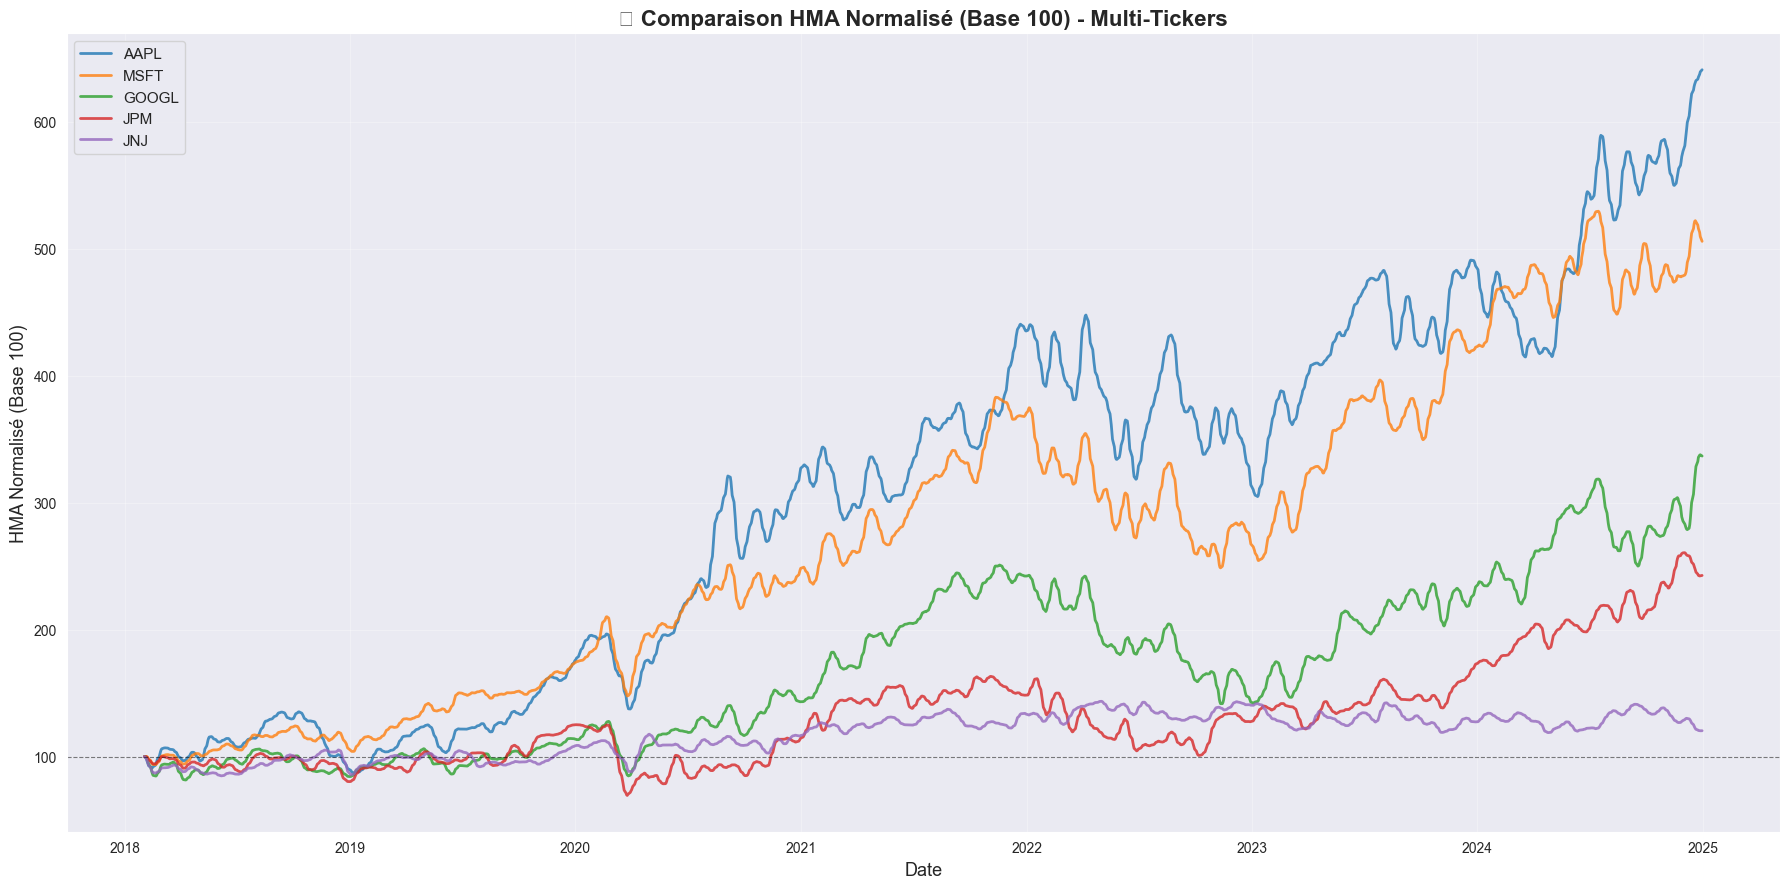

✅ Graphique 2/3: Comparaison HMA multi-tickers


In [9]:
# Visualisation 2: Comparaison HMA pour plusieurs tickers
fig, ax = plt.subplots(figsize=(18, 9))

# Sélectionner 5 tickers pour comparaison
top_tickers = ['AAPL', 'MSFT', 'GOOGL', 'JPM', 'JNJ']

for ticker in top_tickers:
    ticker_data = data_with_indicators[data_with_indicators['Ticker'] == ticker].copy()
    ticker_data = ticker_data.sort_values('Date').dropna(subset=['HMA'])
    
    # Normaliser HMA (base 100)
    ticker_data['HMA_normalized'] = (ticker_data['HMA'] / ticker_data['HMA'].iloc[0]) * 100
    
    ax.plot(ticker_data['Date'], ticker_data['HMA_normalized'], 
            label=ticker, linewidth=2, alpha=0.8)

ax.set_title('📈 Comparaison HMA Normalisé (Base 100) - Multi-Tickers', 
             fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('HMA Normalisé (Base 100)', fontsize=13)
ax.axhline(100, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"✅ Graphique 2/3: Comparaison HMA multi-tickers")


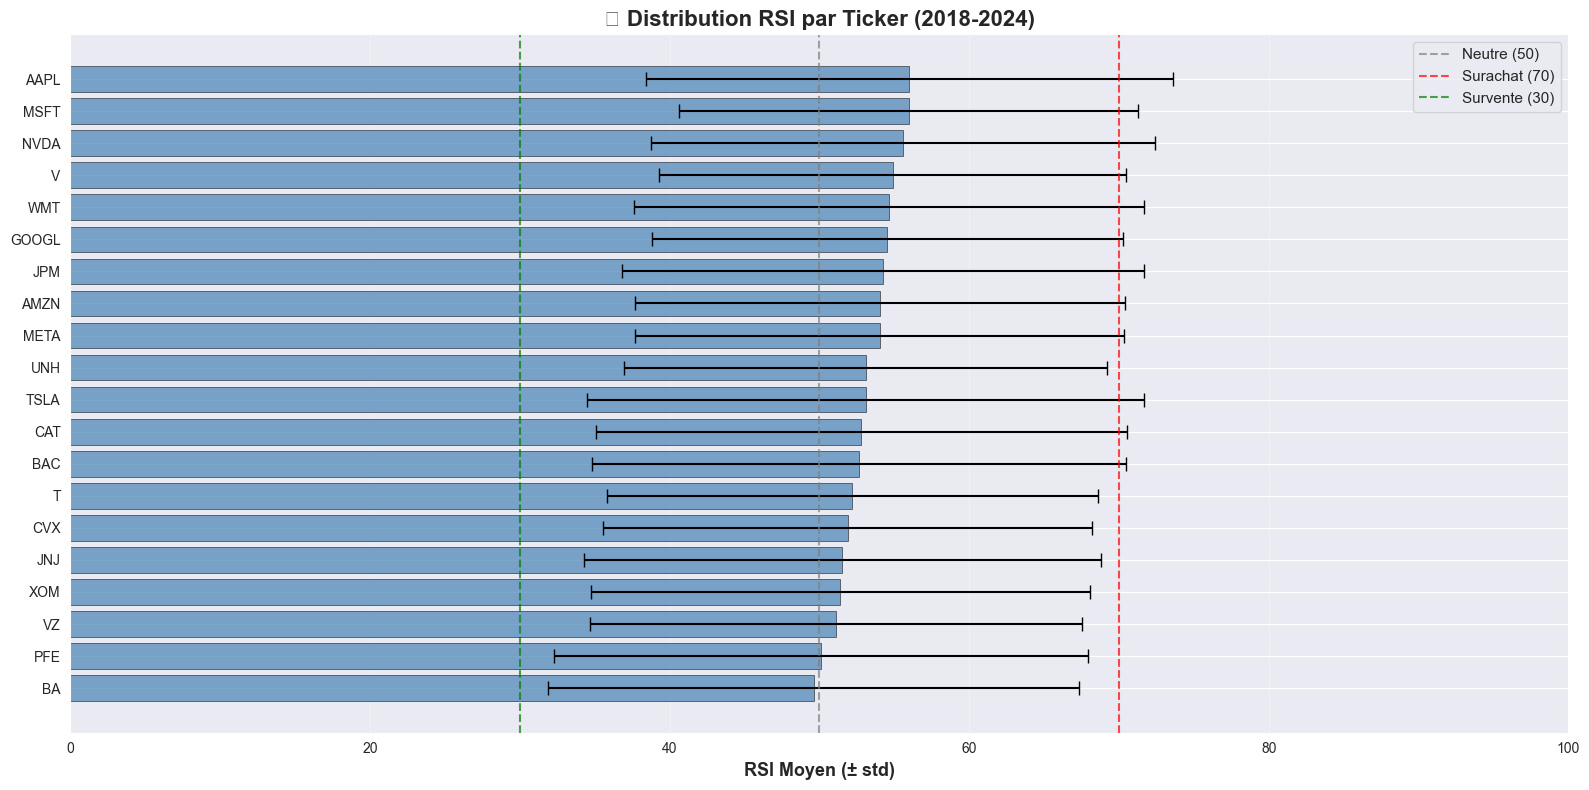

✅ Graphique 3/3: Distribution RSI par ticker


In [10]:
# Visualisation 3: Distribution RSI par ticker
fig, ax = plt.subplots(figsize=(16, 8))

# Calculer RSI moyen par ticker
rsi_by_ticker = data_with_indicators.groupby('Ticker')['RSI'].agg(['mean', 'std']).sort_values('mean')

# Barplot avec erreur
ax.barh(rsi_by_ticker.index, rsi_by_ticker['mean'], 
        xerr=rsi_by_ticker['std'], alpha=0.7, color='steelblue', 
        edgecolor='black', linewidth=0.5, capsize=5)

# Lignes de référence
ax.axvline(50, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label='Neutre (50)')
ax.axvline(70, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Surachat (70)')
ax.axvline(30, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='Survente (30)')

ax.set_xlabel('RSI Moyen (± std)', fontsize=13, fontweight='bold')
ax.set_title('📊 Distribution RSI par Ticker (2018-2024)', fontsize=16, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3, axis='x')
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()

print(f"✅ Graphique 3/3: Distribution RSI par ticker")


In [11]:
# Statistiques détaillées des indicateurs
print("\n" + "="*70)
print("📊 STATISTIQUES DÉTAILLÉES DES INDICATEURS")
print("="*70 + "\n")

indicator_stats = []

for ticker in sorted(data_with_indicators['Ticker'].unique()):
    ticker_data = data_with_indicators[data_with_indicators['Ticker'] == ticker].dropna()
    
    if len(ticker_data) > 0:
        indicator_stats.append({
            'Ticker': ticker,
            'Lignes valides': len(ticker_data),
            'HMA Moyen': round(ticker_data['HMA'].mean(), 2),
            'RSI Moyen': round(ticker_data['RSI'].mean(), 2),
            'MACD Moyen': round(ticker_data['MACD'].mean(), 4),
            'RSI > 70 (%)': round((ticker_data['RSI'] > 70).sum() / len(ticker_data) * 100, 1),
            'RSI < 30 (%)': round((ticker_data['RSI'] < 30).sum() / len(ticker_data) * 100, 1)
        })

stats_df = pd.DataFrame(indicator_stats)
display(stats_df)

print(f"\n📊 RÉSUMÉ GLOBAL:")
print(f"  - RSI moyen global: {data_with_indicators['RSI'].mean():.2f}")
print(f"  - % Surachat (RSI>70): {(data_with_indicators['RSI'] > 70).sum() / len(data_with_indicators.dropna(subset=['RSI'])) * 100:.1f}%")
print(f"  - % Survente (RSI<30): {(data_with_indicators['RSI'] < 30).sum() / len(data_with_indicators.dropna(subset=['RSI'])) * 100:.1f}%")



📊 STATISTIQUES DÉTAILLÉES DES INDICATEURS



,Ticker,Lignes valides,HMA Moyen,RSI Moyen,MACD Moyen,RSI > 70 (%),RSI < 30 (%)
0,AAPL,1738,122.66,56.07,0.8073,23.1,8.3
1,AMZN,1738,129.99,53.85,0.6143,16.7,8.7
2,BA,1738,237.44,49.49,-0.5776,13.6,12.3
3,BAC,1738,29.90,52.46,0.0747,17.6,12.4
4,CAT,1738,190.98,52.76,0.9708,17.5,10.6
5,CVX,1738,108.30,51.89,0.2200,15.1,9.7
6,GOOGL,1738,101.27,54.36,0.5031,17.8,6.6
7,JNJ,1738,134.86,51.52,0.1274,15.4,11.6
8,JPM,1738,123.95,54.09,0.5818,19.2,8.5
9,META,1738,264.70,54.03,1.6581,18.1,8.4



📊 RÉSUMÉ GLOBAL:
  - RSI moyen global: 53.17
  - % Surachat (RSI>70): 17.4%
  - % Survente (RSI<30): 9.3%


In [12]:
# Sauvegarder les données avec indicateurs
print("\n" + "="*70)
print(" SAUVEGARDE DES DONNÉES AVEC INDICATEURS")
print("="*70 + "\n")

output_dir = config.data_dir / 'processed'
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / 'financial_data_with_indicators.csv'
data_with_indicators.to_csv(output_path, index=False)

file_size_mb = output_path.stat().st_size / (1024 * 1024)
print(f" Données sauvegardées: {output_path}")
print(f"   Taille: {len(data_with_indicators):,} lignes × {len(data_with_indicators.columns)} colonnes ({file_size_mb:.2f} MB)")

# Sauvegarder aussi les statistiques
stats_path = output_dir / 'indicators_statistics.csv'
stats_df.to_csv(stats_path, index=False)
print(f" Statistiques sauvegardées: {stats_path}")



 SAUVEGARDE DES DONNÉES AVEC INDICATEURS

 Données sauvegardées: c:\Users\lenovo\OneDrive\Bureau\cours\sentiTrade-HMA-V2\data\processed\financial_data_with_indicators.csv
   Taille: 35,200 lignes × 12 colonnes (6.47 MB)
 Statistiques sauvegardées: c:\Users\lenovo\OneDrive\Bureau\cours\sentiTrade-HMA-V2\data\processed\indicators_statistics.csv


In [13]:
# Résumé final
print("\n" + "="*70)
print(" CALCUL DES INDICATEURS TECHNIQUES TERMINÉ!")
print("="*70)
print(f"✅ {len(data_with_indicators):,} lignes traitées")
print(f"✅ {data_with_indicators['Ticker'].nunique()} tickers")
print(f"✅ {len(data_with_indicators.columns)} colonnes totales")
print(f"✅ Indicateurs ajoutés: HMA, RSI, MACD, MACD_Signal, MACD_Hist")
print(f"✅ Lignes utilisables (sans NaN): {len(data_with_indicators.dropna()):,}")
print()
print("📁 Fichiers générés:")
print(f"  - {output_path.name} ({file_size_mb:.2f} MB)")
print(f"  - {stats_path.name}")
print()
print("📋 PROCHAINE ÉTAPE:")
print("   → Lancer 03_sentiment_analysis.ipynb")
print("   → Analyse de sentiment avec LLM fine-tuné")
print("="*70)



 CALCUL DES INDICATEURS TECHNIQUES TERMINÉ!
✅ 35,200 lignes traitées
✅ 20 tickers
✅ 12 colonnes totales
✅ Indicateurs ajoutés: HMA, RSI, MACD, MACD_Signal, MACD_Hist
✅ Lignes utilisables (sans NaN): 34,760

📁 Fichiers générés:
  - financial_data_with_indicators.csv (6.47 MB)
  - indicators_statistics.csv

📋 PROCHAINE ÉTAPE:
   → Lancer 03_sentiment_analysis.ipynb
   → Analyse de sentiment avec LLM fine-tuné
